# **Loading Packages**
____

In [1]:
import numpy as np
import pandas as pd


from fredapi import Fred

import matplotlib.pyplot as plt

from scipy import stats
from scipy.special import inv_boxcox
from pmdarima.arima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

# **Loading Data**
____

In [21]:
with open("API_key.txt", "r") as file:
    api_key = file.read().strip()

fred = Fred(api_key=api_key)
UK_GDP = fred.get_series('NGDPRSAXDCGBQ')
UK_GDP = pd.DataFrame(UK_GDP)
UK_GDP = UK_GDP.reset_index()

UK_GDP.columns = ['Date', 'GDP'] 

UK_GDP = UK_GDP.set_index('Date')

# **Modeling**
____

## **GDP Model Selection:**

### **SARIMA w/ Original Data**

In [3]:
model_auto = auto_arima(y=UK_GDP['GDP'], start_P=0, 
                        start_q=0, m=4, information_criterion='aic')

In [4]:
print(model_auto)

 ARIMA(2,1,0)(0,0,1)[4] intercept


### **SARIMA w/ Box-Cox Transformation**

In [19]:
UK_GDP['Transformed'], opt_lambda = stats.boxcox(UK_GDP['GDP'])

model_auto_transformed = auto_arima(y=UK_GDP['Transformed'], start_p=0, 
                        start_q=0, m=4,start_P=0, start_Q=0, information_criterion='aic')

In [20]:
print(model_auto_transformed)

 ARIMA(0,1,1)(0,0,1)[4] intercept


### **SARIMA w/ Log Transformation**

In [ ]:
UK_GDP['Log_GDP'] = np.log(UK_GDP['GDP'])

model_auto_log = auto_arima(y=UK_GDP['Log_GDP'], m=4,seasonal=True)

In [ ]:
print(model_auto_log)

### **Comparing Results**

In [7]:
print(model_auto.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  283
Model:             SARIMAX(2, 1, 0)x(0, 0, [1], 4)   Log Likelihood               -2996.144
Date:                             Sun, 08 Feb 2026   AIC                           6002.288
Time:                                     14:58:36   BIC                           6020.497
Sample:                                          0   HQIC                          6009.590
                                             - 283                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   2800.3190    626.400      4.470      0.000    1572.598    4028.040
ar.L1         -0.1721      

In [23]:
print(model_auto_transformed.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  283
Model:             SARIMAX(0, 1, 1)x(0, 0, 1, 4)   Log Likelihood                -549.641
Date:                           Sun, 08 Feb 2026   AIC                           1107.282
Time:                                   17:05:08   BIC                           1121.850
Sample:                               01-01-1955   HQIC                          1113.124
                                    - 07-01-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.4472      0.124      3.604      0.000       0.204       0.690
ma.L1         -0.2575      0.017    -15.301

In [ ]:
print(model_auto_log.summary())

#### **Thoughts**
___
The auto log model significantly outperforms box-cox and the original dataset, thus we will use the given model parameters from the auto-arima function for auto log.

### **Fitting Final Model (GDP)**

/var/folders/ts/x847bxb170n3msnnpmdpjll00000gn/T/ipykernel_65218/1969432115.py:4: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  forecast_index = pd.date_range(start=UK_GDP.index[-1], periods=9, freq='Q')[1:]


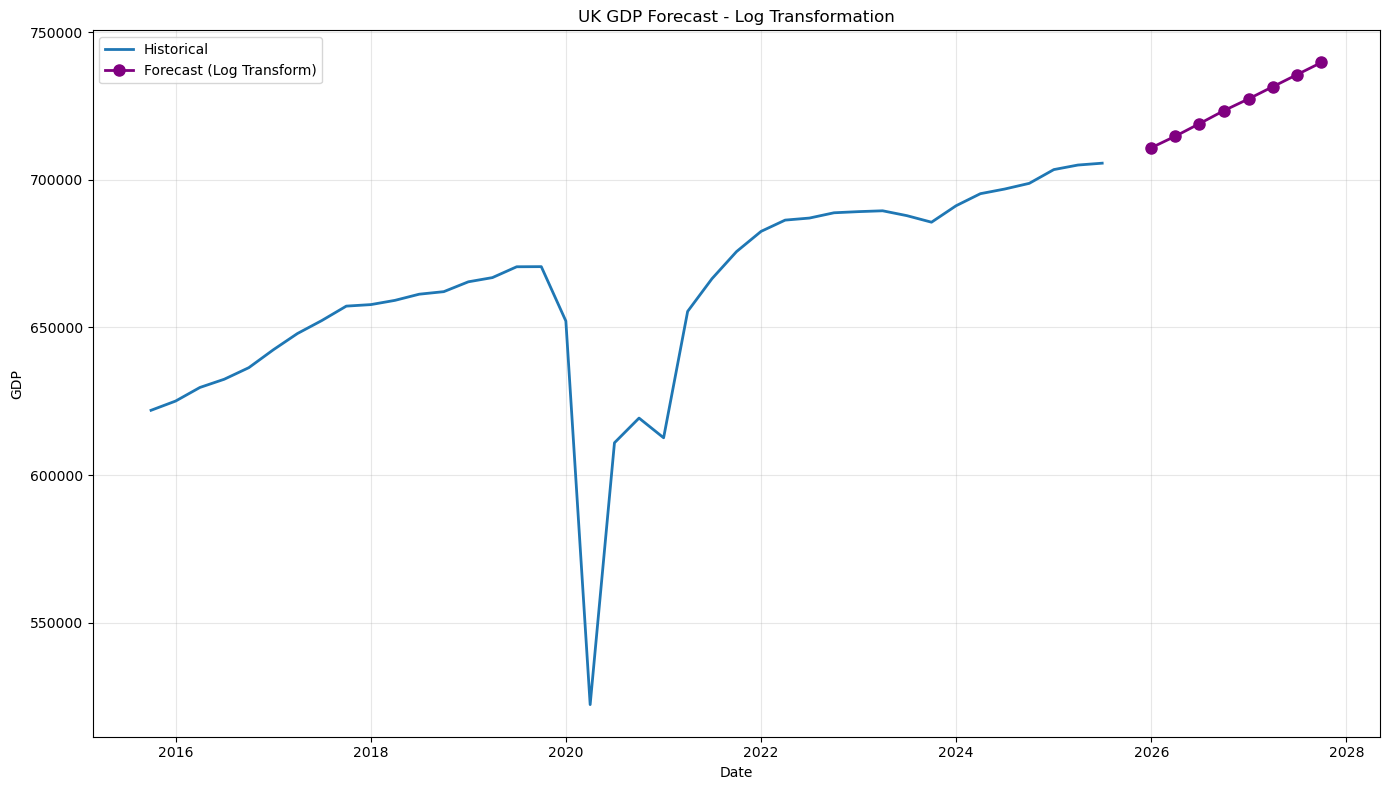

In [25]:
forecast_log = model_auto_log.predict(n_periods=8)
forecast_from_log = np.exp(forecast_log)

forecast_index = pd.date_range(start=UK_GDP.index[-1], periods=9, freq='Q')[1:]

plt.figure(figsize=(14, 8))
recent_data = UK_GDP['GDP'].iloc[-40:]
plt.plot(recent_data.index, recent_data.values, label='Historical', linewidth=2)
plt.plot(forecast_index, forecast_from_log, label='Forecast (Log Transform)', 
         linewidth=2, color='purple', marker='o', markersize=8)
plt.title('UK GDP Forecast - Log Transformation')
plt.ylabel('GDP')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Quick note: Claude was used below to help validate the model more

In [29]:
growth_rates = (np.diff(forecast_from_log) / forecast_from_log[:-1]) * 100
print("\nQuarter-to-Quarter Growth Rates:")
for i, rate in enumerate(growth_rates, 1):
    print(f"Q{i} to Q{i+1}: {rate:.3f}%")

print(f"\nGrowth rate std deviation: {np.std(growth_rates):.5f}%")
print("(Low std = nearly constant growth rate = exponential curve)")


Quarter-to-Quarter Growth Rates:
Q1 to Q2: 0.549%
Q2 to Q3: 0.598%
Q3 to Q4: 0.615%
Q4 to Q5: 0.548%
Q5 to Q6: 0.562%
Q6 to Q7: 0.562%
Q7 to Q8: 0.562%

Growth rate std deviation: 0.02355%
(Low std = nearly constant growth rate = exponential curve)


In [30]:
UK_GDP['QoQ_Growth'] = UK_GDP['GDP'].pct_change() * 100

print("Historical Quarterly Growth Rates:")
print(f"\nLast 5 years (20 quarters):")
print(f"  Mean: {UK_GDP['QoQ_Growth'].iloc[-20:].mean():.3f}%")
print(f"  Std:  {UK_GDP['QoQ_Growth'].iloc[-20:].std():.3f}%")
print(f"  Min:  {UK_GDP['QoQ_Growth'].iloc[-20:].min():.3f}%")
print(f"  Max:  {UK_GDP['QoQ_Growth'].iloc[-20:].max():.3f}%")

print(f"\nLast 10 years (40 quarters):")
print(f"  Mean: {UK_GDP['QoQ_Growth'].iloc[-40:].mean():.3f}%")
print(f"  Std:  {UK_GDP['QoQ_Growth'].iloc[-40:].std():.3f}%")
print(f"  Min:  {UK_GDP['QoQ_Growth'].iloc[-40:].min():.3f}%")
print(f"  Max:  {UK_GDP['QoQ_Growth'].iloc[-40:].max():.3f}%")

Historical Quarterly Growth Rates:

Last 5 years (20 quarters):
  Mean: 0.734%
  Std:  1.605%
  Min:  -1.076%
  Max:  6.982%

Last 10 years (40 quarters):
  Mean: 0.429%
  Std:  4.383%
  Min:  -19.906%
  Max:  16.965%


We can see that the growth is fairly reasonable as a baseline model for GDP growth, being slighting above the 10 year average for quartly growth. However there are a few things to keep an eye on. First, is the convergence of the predicted growth, the last 3 predicted years are all predicted for .562% growth. We will need to adress this since our predictions should range out from 3-5 years. Second thing is the use of exodgenous variables. We may be able to get a better forecast of GDP by using additional variables. The final note is that the small std of our prediction is ok for our baseline secnario, but we will have to think about it as we predict various market conditions. 